In [1]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 48.5 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/Loperaa-Juan/US-Wildfires-Big-Data.git

Cloning into 'US-Wildfires-Big-Data'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 28 (delta 3), reused 28 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 31.26 KiB | 15.63 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [3]:
%cd US-Wildfires-Big-Data

/content/US-Wildfires-Big-Data


In [4]:
!uv sync

Using CPython 3.13.15 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 18 packages in 1ms
Prepared 16 packages in 931ms
Installed 16 packages in 50ms
 + certifi==2026.7.22
 + charset-normalizer==3.5.1
 + idna==3.20
 + kagglehub==1.0.2
 + kagglesdk==0.1.37
 + numpy==2.5.3
 + packaging==26.3
 + pandas==3.0.6
 + protobuf==7.36.2
 + python-dateutil==2.9.0.post0
 + pyyaml==6.0.3
 + requests==2.34.2
 + six==1.17.0
 + tqdm==4.70.1
 + urllib3==2.8.0
 + us-wildfires-big-data==0.1.0 (from file:///content/US-Wildfires-Big-Data)


In [5]:
import os

# Reemplaza los valores con los que están dentro de tu kaggle.json
os.environ['KAGGLE_USERNAME'] = "antonio2004"
os.environ['KAGGLE_KEY'] = "b0714d0c6a8078ab2129f2959683571c"

# Ejecutar la descarga del dataset
!uv run scripts/download.py

Using Colab cache for faster access to the '188-million-us-wildfires' dataset.
Path to dataset files: /kaggle/input/188-million-us-wildfires


In [7]:
import os
import glob
import shutil

# 1. Asegurar que exista la carpeta data/raw/
os.makedirs("data/raw", exist_ok=True)

# 2. Buscar el archivo .sqlite en la ruta donde Kaggle guardó la descarga
kaggle_path = "/kaggle/input/188-million-us-wildfires"
sqlite_files = glob.glob(f"{kaggle_path}/**/*.sqlite", recursive=True)

if sqlite_files:
    src_file = sqlite_files[0]
    dst_file = os.path.join("data/raw", os.path.basename(src_file))

    # Copiar o mover el archivo a data/raw/
    shutil.copy(src_file, dst_file)
    print(f"✅ Archivo movido exitosamente a: {dst_file}")
else:
    print("❌ No se encontró ningún archivo .sqlite en la ruta de Kaggle. Revisa la descarga.")

✅ Archivo movido exitosamente a: data/raw/FPA_FOD_20170508.sqlite


In [8]:
!uv run scripts/transform.py

In [9]:
import pandas as pd

# Verificar que el CSV exista y leer las primeras filas
df = pd.read_csv("data/processed/fires.csv")
print(f"✅ Archivo generado exitosamente con {len(df):,} filas.")
df.head()

/tmp/ipykernel_3495/1414836372.py:4: DtypeWarning: Columns (8,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/fires.csv")


✅ Archivo generado exitosamente con 1,880,465 filas.


,fod_id,fire_name,fire_year,stat_cause_descr,fire_size,fire_size_class,owner_descr,state,county,latitude,longitude,discovery_dt,cont_dt
0,1,FOUNTAIN,2005,Miscellaneous,0.10,A,USFS,CA,63.0,40.036944,-121.005833,2005-02-02 13:00:00,2005-02-02 17:30:00
1,2,PIGEON,2004,Lightning,0.25,A,USFS,CA,61.0,38.933056,-120.404444,2004-05-12 08:45:00,2004-05-12 15:30:00
2,3,SLACK,2004,Debris Burning,0.10,A,STATE OR PRIVATE,CA,17.0,38.984167,-120.735556,2004-05-31 19:21:00,2004-05-31 20:24:00
3,4,DEER,2004,Lightning,0.10,A,USFS,CA,3.0,38.559167,-119.913333,2004-06-28 16:00:00,2004-07-03 14:00:00
4,5,STEVENOT,2004,Lightning,0.10,A,USFS,CA,3.0,38.559167,-119.933056,2004-06-28 16:00:00,2004-07-03 12:00:00


Analisis exploratorio

In [10]:
# Cargar datos evitando advertencias de tipo de dato
df = pd.read_csv("data/processed/fires.csv", low_memory=False)

# Resumen general del conjunto de datos
print("--- Información del Dataset ---")
df.info()

print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

print("\n--- Resumen Estadístico de Variables Numéricas ---")
display(df.describe())

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1880465 entries, 0 to 1880464
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   fod_id            int64  
 1   fire_name         object 
 2   fire_year         int64  
 3   stat_cause_descr  object 
 4   fire_size         float64
 5   fire_size_class   object 
 6   owner_descr       object 
 7   state             object 
 8   county            object 
 9   latitude          float64
 10  longitude         float64
 11  discovery_dt      object 
 12  cont_dt           object 
dtypes: float64(3), int64(2), object(8)
memory usage: 186.5+ MB

--- Conteo de Valores Nulos ---
fod_id                   0
fire_name           960479
fire_year                0
stat_cause_descr         0
fire_size                0
fire_size_class          0
owner_descr              0
state                    0
county              678148
latitude                 0
longitude              

,fod_id,fire_year,fire_size,latitude,longitude
count,1.880465e+06,1.880465e+06,1.880465e+06,1.880465e+06,1.880465e+06
mean,5.484020e+07,2.003710e+03,7.452016e+01,3.678121e+01,-9.570494e+01
std,1.011963e+08,6.663099e+00,2.497598e+03,6.139031e+00,1.671694e+01
min,1.000000e+00,1.992000e+03,1.000000e-05,1.793972e+01,-1.788026e+02
25%,5.055000e+05,1.998000e+03,1.000000e-01,3.281860e+01,-1.103635e+02
50%,1.067761e+06,2.004000e+03,1.000000e+00,3.545250e+01,-9.204304e+01
75%,1.910639e+07,2.009000e+03,3.300000e+00,4.082720e+01,-8.229760e+01
max,3.003484e+08,2.015000e+03,6.069450e+05,7.033060e+01,-6.525694e+01


In [15]:
import pandas as pd

# Filtrar solo columnas de tipo texto (object / string)
text_cols = df.select_dtypes(include=['object']).columns

print("--- REPORTE DETALLADO: NULOS VS. VACÍOS ---")
for col in text_cols:
    nulos = df[col].isnull().sum()
    vacio_exacto = (df[col] == "").sum()
    solo_espacios = (df[col].astype(str).str.strip() == "").sum() - nulos - vacio_exacto

    print(f"Columna '{col}':")
    print(f"  - Nulos (NaN): {nulos:,}")
    print(f"  - Vacíos (\"\"): {vacio_exacto:,}")
    print(f"  - Solo espacios (\" \"): {solo_espacios:,}")
    print("-" * 40)

--- REPORTE DETALLADO: NULOS VS. VACÍOS ---
Columna 'fire_name':
  - Nulos (NaN): 960,479
  - Vacíos (""): 0
  - Solo espacios (" "): -960,479
----------------------------------------
Columna 'stat_cause_descr':
  - Nulos (NaN): 0
  - Vacíos (""): 0
  - Solo espacios (" "): 0
----------------------------------------
Columna 'fire_size_class':
  - Nulos (NaN): 0
  - Vacíos (""): 0
  - Solo espacios (" "): 0
----------------------------------------
Columna 'owner_descr':
  - Nulos (NaN): 0
  - Vacíos (""): 0
  - Solo espacios (" "): 0
----------------------------------------
Columna 'state':
  - Nulos (NaN): 0
  - Vacíos (""): 0
  - Solo espacios (" "): 0
----------------------------------------
Columna 'county':
  - Nulos (NaN): 678,148
  - Vacíos (""): 0
  - Solo espacios (" "): -678,148
----------------------------------------
Columna 'discovery_dt':
  - Nulos (NaN): 0
  - Vacíos (""): 0
  - Solo espacios (" "): 0
----------------------------------------
Columna 'cont_dt':
  - Nulos (

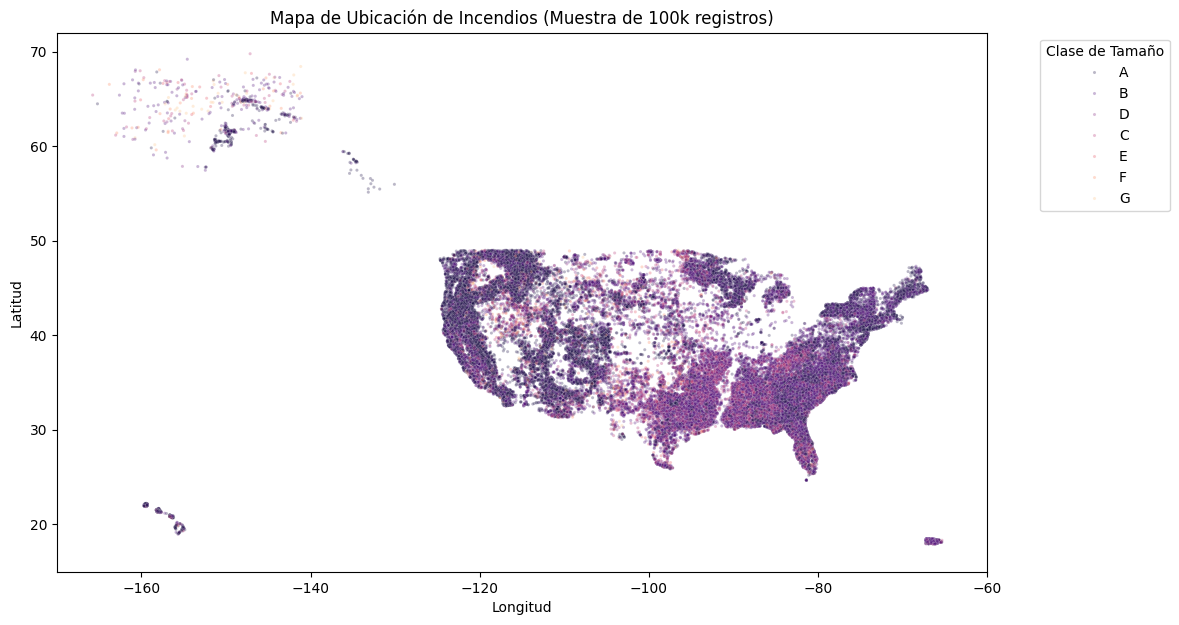

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df.sample(n=100000, random_state=42), # Muestra representativa para fluidez
    x='longitude',
    y='latitude',
    hue='fire_size_class',
    alpha=0.3,
    s=5,
    palette='magma'
)
plt.title('Mapa de Ubicación de Incendios (Muestra de 100k registros)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.xlim(-170, -60) # Enfocar Estados Unidos
plt.ylim(15, 72)
plt.legend(title='Clase de Tamaño', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Columna de County (Estado)

In [24]:
print("Top 10 condados (excluyendo nulos):")
print(df['county'].value_counts(dropna=True).head(10))

Top 10 condados (excluyendo nulos):
county
5             7576
Lincoln       7405
SUFFOLK       7373
Polk          6955
Washington    6916
Cherokee      6796
Oahu          6777
Marion        6657
Jackson       6305
Lee           5914
Name: count, dtype: int64


In [25]:
# Ver de qué estados son los registros donde county == '5' (o 5)
df[df['county'].astype(str) == '5']['state'].value_counts()

,count
state,
AZ,5943
OR,950
SC,99
NV,92
ID,87
WI,72
WY,64
CA,59
UT,59


In [29]:
import geopandas as gpd

# 1. Cargar el mapa vectorial de CONDADOS de EE. UU.
url_condados = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
mapa_condados = gpd.read_file(url_condados)

# 2. Re-proyectar el GeoDataFrame de tus datos al CRS del mapa de condados
gdf = gdf.to_crs(mapa_condados.crs)

# 3. Hacer el Spatial Join con el mapa de condados ('NAME' trae el nombre del condado)
gdf_condados = gpd.sjoin(gdf, mapa_condados[['NAME', 'geometry']], how='left', predicate='within')

# 4. Asignar el resultado a una nueva columna o sobrescribir 'county'
df['county_calculado'] = gdf_condados['NAME']

# Ver los datos resultantes
print(df[['state', 'county', 'county_calculado']].head(10))

  state county county_calculado
0    CA     63           Plumas
1    CA     61        El Dorado
2    CA     17        El Dorado
3    CA      3           Alpine
4    CA      3           Alpine
5    CA      5           Amador
6    CA     17        El Dorado
7    CA    NaN           Shasta
8    CA    NaN         Siskiyou
9    CA      5           Amador


In [30]:
# Opción A (Recomendada): Sobrescribir la columna 'county' con el nombre real
df['county'] = df['county_calculado']
df = df.drop(columns=['county_calculado'])

# Opcional: Eliminar cualquier columna residual creada por el spatial join si existe
if 'index_right' in df.columns:
    df = df.drop(columns=['index_right'])

# Verificar cuántos nulos quedan en 'county'
print("Valores nulos restantes en county:", df['county'].isnull().sum())
print("\nTop 10 condados limpios:")
print(df['county'].value_counts().head(10))

Valores nulos restantes en county: 1940

Top 10 condados limpios:
county
Riverside     19221
Lincoln       17780
Coconino      15681
Jackson       14456
Washington    14306
Jefferson     12323
Marion        12254
Cherokee      11667
Lake          10468
Beltrami      10167
Name: count, dtype: int64


In [31]:
# Opción 1: Configurar pandas para mostrar todas las filas sin truncar
import pandas as pd

pd.set_option('display.max_rows', None)
print(df['county'].value_counts(dropna=False))

# Restaurar el límite por defecto de pandas si lo necesitas después
pd.reset_option('display.max_rows')

county
Riverside                19221
Lincoln                  17780
Coconino                 15681
Jackson                  14456
Washington               14306
Jefferson                12323
Marion                   12254
Cherokee                 11667
Lake                     10468
Beltrami                 10167
Monroe                   10047
Grant                     9821
Polk                      9774
Lee                       9569
San Diego                 9562
Wayne                     9141
Gila                      9037
Humboldt                  8841
San Bernardino            8642
Tulare                    8470
Douglas                   8418
Fresno                    8373
Union                     8113
Merced                    7737
Suffolk                   7731
Richmond                  7425
Jasper                    7337
Idaho                     7299
Oglala Lakota             7060
Orange                    6962
Maricopa                  6922
Franklin                  6916
C

In [32]:
df.to_parquet('US_Wildfires_Limpio.parquet', index=False)
# O si prefieres CSV tradicional:
# df.to_csv('US_Wildfires_Limpio.csv', index=False)